### Import and reading data

In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
# import os
# import ctypes

# # Force the dynamic linker to find libR.so before rpy2 tries to load
# try:
#     ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
# except Exception as e:
#     print(f"Manual link failed: {e}")

# os.environ['R_HOME'] = '/usr/lib/R'
# os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

In [82]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [83]:
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
os.chdir('/home/dell/projects/graphical-sampling/simulations')

In [84]:
# ============================================================
# DESIGN SEARCH FUNCTION
# ============================================================

def search_best_design(
    pop,
    n,

    criterion='MI',

    point_strategies=None,
    zone_strategies=None,

    zone_modes=['sweep_xy', 'sweep_yx'],

    num_splits=[0],
    shift_jumps=[1],

    num_zones_cluster=[100],
    num_zones_sweep=[(5, 5)],

    centroid_grid_x=10,
    r_sample_per_cluster=1,

    topological=True,
    shuffle=False,
):

    # --------------------------------------------------------
    # DEFAULT STRATEGIES
    # --------------------------------------------------------

    if point_strategies is None:

        point_strategies = [
            'None',
            'lexico_xy',
            'lexico_yx',
            'projection',
            'dist_from_origin',
            'angle',
            'spiral',
            'hilbert',
            'snake',
            'knight_move',
            'random',
        ]

    if zone_strategies is None:
        zone_strategies = point_strategies

    # --------------------------------------------------------
    # CRITERION MAP
    # --------------------------------------------------------

    criterion_map = {

        'MI': lambda d: d.moran[0],

        'VI': lambda d: d.voronoi,

        'DI': lambda d: d.density_disparity,

        'BI': lambda d: d.local_balance,

        'VAR': lambda d: d.nht_variance,
    }

    criterion_name_map = {

        'MI': 'Moran',
        'VI': 'Voronoi',
        'DI': 'Density',
        'BI': 'Balance',
        'VAR': 'Variance',
    }

    evaluator = criterion_map[criterion]

    criterion_name = criterion_name_map[criterion]

    # --------------------------------------------------------
    # STORAGE
    # --------------------------------------------------------

    track = []

    best_val = float('inf')

    best_design = None

    # --------------------------------------------------------
    # TOTAL ITERATIONS
    # --------------------------------------------------------

    num_designs = (
        len(point_strategies)
        * len(zone_strategies)
        * len(zone_modes)
        * len(num_splits)
        * len(shift_jumps)
    )

    # --------------------------------------------------------
    # PROGRESS BAR
    # --------------------------------------------------------

    pbar = tqdm(
        product(
            point_strategies,
            zone_strategies,
            zone_modes,
            num_splits,
            shift_jumps
        ),
        total=num_designs
    )

    # ========================================================
    # SEARCH LOOP
    # ========================================================

    for (
        point_strategy,
        zone_strategy,
        zone_mode,
        num_split,
        shift_jump
    ) in pbar:

        list_of_num_zones = (
            num_zones_cluster
            if zone_mode == 'cluster'
            else num_zones_sweep
        )

        for num_zones in list_of_num_zones:

            # ------------------------------------------------
            # CLUSTERING
            # ------------------------------------------------

            fbn = gs.clustering.FIPBalancedNMeans(

                n=n,

                centroid_grid_x=centroid_grid_x,

                r_sample_per_cluster=r_sample_per_cluster,

                init_clust_method='expanded',

                split_size=1
            )

            fbn.fit(pop)

            fbn.fit_zones(
                num_zones=num_zones,
                mode=zone_mode
            )

            try:

                # --------------------------------------------
                # ORDER
                # --------------------------------------------

                order = gs.Order.from_clusters(

                    pop,

                    fbn.clusters,

                    zone_strategy=zone_strategy,

                    point_strategy=point_strategy,

                    num_splits=num_split,

                    topological=topological,

                    shift_jump=shift_jump,

                    shuffle=shuffle,

                    grid_dims=(
                        num_zones
                        if isinstance(num_zones, tuple)
                        else None
                    ),
                )

                # --------------------------------------------
                # DESIGN
                # --------------------------------------------

                design = gs.Design.from_order(pop, order)

                # --------------------------------------------
                # VARIANCE RESET
                # --------------------------------------------

                if criterion == 'VAR':
                    design._nht_variance = None

                # --------------------------------------------
                # EVALUATION
                # --------------------------------------------

                val = evaluator(design)

                # --------------------------------------------
                # INITIAL BASELINE
                # --------------------------------------------

                if len(track) == 0:

                    best_val = val

                    print(
                        f"[INITIAL BASELINE] "
                        f"{criterion_name}: {val:.6f}"
                    )

                # --------------------------------------------
                # IMPROVEMENT
                # --------------------------------------------

                if val < best_val:

                    best_val = val

                    best_design = design

                    print(
                        f"[NEW BEST] "
                        f"{criterion_name}: {val:.6f} | "
                        f"ZS: {str(zone_strategy):<15} | "
                        f"PS: {str(point_strategy):<15} | "
                        f"Jump: {shift_jump}"
                    )

                # --------------------------------------------
                # PROGRESS
                # --------------------------------------------

                pbar.set_postfix({
                    criterion_name: f"{best_val:.6f}"
                })

                # --------------------------------------------
                # STORAGE
                # --------------------------------------------

                track.append((
                    val,
                    design,
                    zone_strategy,
                    point_strategy,
                    zone_mode,
                    num_zones,
                    shift_jump
                ))

            except Exception:
                continue

    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    if not track:

        print("\n[ERROR] No valid designs generated.")

        return None

    results = sorted(track, key=lambda x: x[0])

    best = results[0]

    print(f"\n{'='*45}")
    print(f"      OPTIMIZATION COMPLETE")
    print(f"{'='*45}")

    print(f"Best {criterion_name}: {best[0]:.6f}")
    print(f"Zone Strategy:  {best[2]}")
    print(f"Point Strategy: {best[3]}")
    print(f"Zone Mode:      {best[4]}")
    print(f"Num Zones:      {best[5]}")
    print(f"Shift Jump:     {best[6]}")

    print(f"{'='*45}")

    return {
        'best_design': best[1],
        'best_value': best[0],
        'results': results,
        'track': track,
    }

In [85]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )

        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        if f in [

            "AggregatedPop1000.csv",

            "RegularPop1000.csv"
        ]:

            coords = df.to_numpy()

            x1 = coords[:, 0]

            x2 = coords[:, 1]

            # Corrugated plane variable
            z = (

                3*(x1 + x2)

                +

                np.sin(
                    6*(x1 + x2)
                )
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,

                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : z
            })

        # =================================================
        # MEUSE
        # =================================================

        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 4)
aggregated: (1000, 4)
meuse: (155, 5)
swiss: (959, 5)


In [86]:
# changing the angle of the population for testing the robustness of the sampling algorithms

import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

In [87]:
# Diagnostic function to check inclusion probabilities and plot deviations

import numpy as np
import matplotlib.pyplot as plt

def check_inclusions(design, plot=True, title="FIP Deviation"):
    """
    Performs a statistical diagnostic on the design to ensure 
    Inclusion Probabilities (FIP) are perfectly preserved.
    """
    # 1. Extract Data
    empirical_fip = design.fip 
    target_fip = design.pop.inclusions
    diff = empirical_fip - target_fip
    max_dev = np.abs(diff).max()

    # 2. Print Summary
    print(f"--- Inclusion Probability Diagnostic ---")
    print(f"Total Design Mass: {empirical_fip.sum():.6f} (Target: {design.pop.n})")
    print(f"Max Absolute Deviation: {max_dev:.2e}")
    print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

    # 3. Validation Logic
    if np.allclose(empirical_fip, target_fip, atol=1e-6):
        print("✅ SUCCESS: Inclusion probabilities are perfectly preserved!")
    else:
        fixed_count = len(design.order.fixed_ids)
        print(f"❌ WARNING: Significant deviation! Frozen units: {fixed_count}")

    # 4. Optional Plotting
    if plot:
        plt.figure(figsize=(10, 2))
        plt.plot(diff, color='red', lw=1, alpha=0.7)
        plt.title(f"{title} (Max Dev: {max_dev:.2e})")
        plt.axhline(0, color='black', lw=0.5, ls='--')
        plt.ylabel("Delta")
        plt.xlabel("Unit Index")
        plt.grid(True, alpha=0.2)
        plt.show()

In [88]:
# Function to save the full GBFS engine state, including the search frontier and best design
import os
import pickle
from datetime import datetime

def save_gbfs_state(engine, folder="best_designs"):
    """
    Saves the full GBFS engine state, including the search frontier and best design.
    """
    os.makedirs(folder, exist_ok=True)
    
    # Extract metadata for a clean filename
    pop_label = getattr(engine.best_design.pop, 'label', 'pop').replace(" ", "_")
    score = engine.best_criteria_value
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Detect current zone configuration from the best design
    # This helps identify if the file is a 40Z or 1Z version
    num_clusters = len(engine.best_design.order.clusters)
    num_zones = len(engine.best_design.order.clusters[0].zones) if num_clusters > 0 else 0
    
    filename = f"GRIZZLY_{pop_label}_C{num_clusters}Z{num_zones}_score{score:.4f}_pop_{popu}_{timestamp}.pkl"
    save_path = os.path.join(folder, filename)
    
    with open(save_path, 'wb') as f:
        pickle.dump(engine, f)
    
    print(f"✅ Full search state saved: {save_path}")
    print(f"Candidates waiting in Open Set: {len(engine.open_set)}")
    return save_path

In [89]:
# Function to Save Initila and Best Design, 
import os
import pickle
from datetime import datetime

def save_design(design, folder="best_designs", name_prefix="INITIAL"):
    """
    Save a single Design object.
    """
    os.makedirs(folder, exist_ok=True)

    # Population label
    pop_label = getattr(design.pop, 'label', 'pop').replace(" ", "_")

    # Structure info
    num_clusters = len(design.order.clusters) if design.order.clusters else 1
    num_zones = len(design.order.clusters[0].zones) if design.order.clusters else 1

    # Timestamp
    timestamp = datetime.now().strftime("%m%d_%H%M")

    filename = (
        f"{name_prefix}_{pop_label}"
        f"_C{num_clusters}Z{num_zones}"
        f"_pop_{popu}_{timestamp}.pkl"
    )

    save_path = os.path.join(folder, filename)

    with open(save_path, 'wb') as f:
        pickle.dump(design, f)

    print(f"✅ Design saved: {save_path}")

    return save_path

In [90]:
# Function to load a saved GBFS engine state from the best_designs folder

def load_gbfs_state(filename):
    """
    Loads a saved GBFS engine state from the best_designs folder.
    """
    # Ensure we look in the right folder if only a filename is provided
    if not os.path.exists(filename):
        filename = os.path.join("best_designs", filename)
        
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            loaded_engine = pickle.load(f)
        
        print(f"🚀 Grizzly Resumed!")
        print(f"Best Score Found: {loaded_engine.best_criteria_value:.6f}")
        print(f"Hierarchy State:  {len(loaded_engine.best_design.order.clusters)} Clusters")
        print(f"Frontier Size:    {len(loaded_engine.open_set)} candidates")
        return loaded_engine
    else:
        print(f"❌ File not found: {filename}")
        return None

In [91]:
# Fucntion to load One Design, Best or Initial
import pickle

def load_design(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

In [92]:
def release_full_grizzly(old_engine):
    """
    Takes a restricted engine (40 zones), flattens every single candidate 
    in its open_set, and returns a brand new 'Released' engine.
    """
    print(f"--- Global Release Initiated ---")
    print(f"Processing {len(old_engine.open_set)} candidates from the frontier...")
    
    # 1. First, flatten the absolute best design to use as the "seed"
    flat_best = old_engine.best_design.flatten()
    
    # 2. Create the fresh engine using that flat_best as the initial design
    # This prevents the ValueError: min() arg is empty
    new_engine = gs.search.GreedyBestFirstSearch(initial_designs=[flat_best], criteria=old_engine.criteria)
    
    # 3. Flatten the rest of the Open Set and add them
    flattened_count = 0
    import heapq
    for val, _, move_type, design in old_engine.open_set:
        try:
            # Flatten the candidate
            flat_candidate = design.flatten()
            
            # Avoid duplicating the best_design we already added
            if flat_candidate == flat_best:
                continue
                
            # Push into the new engine's open_set
            heapq.heappush(new_engine.open_set, (val, next(new_engine._counter), 'order_change', flat_candidate))
            flattened_count += 1
        except Exception:
            continue
            
    # 4. Ensure the engine starts with a clean closed_set
    new_engine.closed_set = set()
    
    print(f"✅ Success! New engine populated with {flattened_count + 1} global candidates.")
    print(f"Current Best Score: {new_engine.best_criteria_value:.6f}")
    
    return new_engine

In [93]:
# Debugging function to visualize the swap in the specific zone

from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np
def audit_intelligent_swap(order_obj, coords, idx_i, idx_j, c_idx, z_idx):
    """
    Visualizes the specific zone where a swap is happening.
    """
    plt.figure(figsize=(6, 6))
    
    # 1. Get the specific zone data
    active_zone = order_obj.clusters[c_idx].zones[z_idx]
    zone_indices = active_zone.indices # Use the property to get sorted indices
    
    # 2. Plot all points in the background (faint)
    plt.scatter(coords[:, 0], coords[:, 1], c='gray', s=5, alpha=0.1, label='Population')
    
    # 3. Highlight all points in this SPECIFIC zone
    zone_coords = coords[zone_indices]
    plt.scatter(zone_coords[:, 0], zone_coords[:, 1], c='green', s=20, alpha=0.4, label=f'Zone {z_idx}')
    
    # 4. Draw the Convex Hull of the Zone (The "Green Box")
    if len(zone_coords) >= 3:
        hull = ConvexHull(zone_coords)
        for simplex in hull.simplices:
            plt.plot(zone_coords[simplex, 0], zone_coords[simplex, 1], 'g-', lw=2)
            
    # 5. Highlight the two units being swapped
    # Red = Unit i, Blue = Unit j
    plt.scatter(coords[idx_i, 0], coords[idx_i, 1], c='red', s=100, edgecolors='black', label='Unit I', zorder=5)
    plt.scatter(coords[idx_j, 0], coords[idx_j, 1], c='blue', s=100, edgecolors='black', label='Unit J', zorder=5)
    
    plt.title(f"Cluster {c_idx} | Zone {z_idx} | Swapping ID {idx_i} with {idx_j}")
    plt.legend()
    plt.show()

In [94]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


### Parameters

<Axes: title={'center': 'FIP Balanced 50-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

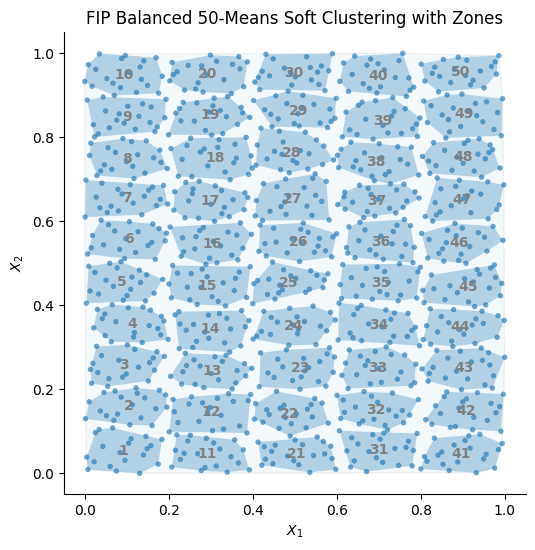

In [72]:
# --- Parameters ---
popu = 'df_RegularPop1000'
ep_or_up = 'pik_ep'
n = 50
df = popus(n)[popu]
df = rotate_population(df.copy(),0)
N = len(df)

r_sample_per_cluster = 50
centroid_grid_x =4
centroid_grid_x_zone = 9
num_zones_cluster = [100]
num_zones_sweep = [(5, 10)]
num_splits = [1]
topological = True
shift_jumps = [0,2]
shuffle=False

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
# np.random.seed(123)
# inclusions_data = np.sort(inclusion_probabilities(
#     np.clip(np.random.random(N), .3, .8),
#     n
# ))
variable_data = target_df['z'].to_numpy() if 'z' in target_df.columns else inclusions_data

# --- Population & Clustering ---
pop = gs.Population(coords_data, inclusions_data, n=n, variable=variable_data)

fbn = gs.clustering.FIPBalancedNMeans(
    n=n, 
    centroid_grid_x=centroid_grid_x, 
    r_sample_per_cluster=r_sample_per_cluster, 
    init_clust_method='expanded', 
    split_size=1
)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_xy')
# fbn.fit_zones(num_zones=num_zones_cluster[0], mode='cluster')

# --- Visualization ---
fbn.plot(mode='soft')

### Pre-Process

In [98]:
out = search_best_design(

    pop=pop,

    n=n,
    r_sample_per_cluster = n,
    centroid_grid_x =1,
    num_zones_cluster = [100],
    num_zones_sweep = [(20, 10)],
    num_splits = [1],
    topological = True,
    shift_jumps = [0],
    shuffle=False,

    criterion='VAR',
)

best_design = out['best_design']

  0%|          | 0/242 [00:00<?, ?it/s]

  2%|▏         | 4/242 [00:00<00:13, 17.56it/s, Variance=28446.450018]

[INITIAL BASELINE] Variance: 30821.969733
[NEW BEST] Variance: 28446.450018 | ZS: lexico_xy       | PS: None            | Jump: 0


  3%|▎         | 8/242 [00:00<00:14, 16.24it/s, Variance=10549.167292]

[NEW BEST] Variance: 14981.405318 | ZS: projection      | PS: None            | Jump: 0
[NEW BEST] Variance: 10549.167292 | ZS: projection      | PS: None            | Jump: 0


...

[NEW BEST] Variance: 431.797981 | ZS: hilbert         | PS: spiral          | Jump: 0
[NEW BEST] Variance: 425.798286 | ZS: snake           | PS: spiral          | Jump: 0


 99%|█████████▉| 240/242 [00:17<00:00, 13.89it/s, Variance=353.831418]

[NEW BEST] Variance: 353.831418 | ZS: snake           | PS: random          | Jump: 0


100%|██████████| 242/242 [00:17<00:00, 14.03it/s, Variance=353.831418]


      OPTIMIZATION COMPLETE
Best Variance: 353.831418
Zone Strategy:  snake
Point Strategy: random
Zone Mode:      sweep_yx
Num Zones:      (20, 10)
Shift Jump:     0


In [73]:
# Initial Search to find best combination!
# all_strategies = ['None' ,'lexico_yx', 'projection', 'spiral', 'angle', 
#                     'dist_from_origin', 'dist_from_centroids', 'max_coord', 'lexico_xy', 'snake', 'knight_move', 'hilbert', 'snake_refined',
#                     'hilbert_strong', 'morton_grts', 'snake_staggered']
all_strategies = [
    'None',

    # Lexicographic
    'lexico_xy',
    'lexico_yx',

    # Geometric
    'projection',
    'dist_from_origin',
    'angle',
    'spiral',

    # Space-filling / GRTS-like
    'hilbert',
    # 'hilbert_strong',
    # 'morton_grts',

    # Snake family
    'snake',
    # 'snake_staggered',

    # Block / knight traversal
    'knight_move',

    # Random baseline
    'random',
]
point_strategies = all_strategies
        
# point_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
# point_strategies = ['knight_move']

zone_strategies = all_strategies
                  
# zone_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
# zone_strategies = ['lexico_yx']
zone_modes = ['sweep_xy', 'sweep_yx']
#zone_modes = ['cluster']
# Ensure shift_jumps is defined in your notebook before this

initial_designs = []
track = []
min_moran = float('inf') 

# Correct calculation for total iterations
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits) * len(shift_jumps)

# Initialize Progress Bar
pbar = tqdm(product(point_strategies, zone_strategies, zone_modes, num_splits, shift_jumps), total=num_designs)

for point_strategy, zone_strategy, zone_mode, num_split, shift_jump in pbar:
    
    # Selection of zone counts
    list_of_num_zones = num_zones_cluster if zone_mode == 'cluster' else num_zones_sweep

    for num_zones in list_of_num_zones:
        # 1. Fresh Clustering
        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=centroid_grid_x, 
            r_sample_per_cluster=r_sample_per_cluster, 
            init_clust_method='expanded', 
            split_size=1
        )
        fbn.fit(pop)
        fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
        
        # 2. Build Order
        try:
            # IMPORTANT: Set shuffle=True here to use your new Prime Phase Shift logic
            order = gs.Order.from_clusters(
                pop, 
                fbn.clusters, 
                zone_strategy=zone_strategy, 
                point_strategy=point_strategy, 
                num_splits=num_split,
                topological=topological,
                shift_jump=shift_jump,
                shuffle=shuffle,
                # THE FIX: Only pass as tuple, otherwise let it auto-calculate
                grid_dims=num_zones if isinstance(num_zones, tuple) else None,
            )

            # 3. Create Design
            design = gs.Design.from_order(pop, order)

            # 4. Evaluate Moran Index
            moran_val = design.moran[0]
            
            # --- BASELINE FIX: Print the very first valid result ---
            if len(track) == 0:
                min_moran = moran_val
                print(f"[INITIAL BASELINE] Moran: {moran_val:.6f} | ZS: {zone_strategy} | PS: {point_strategy}")

            # --- IMPROVEMENT LOGIC ---
            if moran_val < min_moran:
                min_moran = moran_val
                # Using aligned printing for clarity
                print(f"[NEW BEST] Moran: {moran_val:.6f} | ZS: {str(zone_strategy):<15} | PS: {str(point_strategy):<15} | Jump: {shift_jump}")
            
            # Show live status next to the bar
            pbar.set_postfix({"Best": f"{min_moran:.6f}"})

            initial_designs.append(design)
            track.append((moran_val, design, zone_strategy, point_strategy, zone_mode, num_zones, shift_jump))
            
        except Exception as e:
            # If everything shows nothing, comment out 'continue' and uncomment 'raise e' to see why
            continue

# --- Final Ranking Output ---
if not track:
    print("\n[ERROR] No designs were successfully generated. Check your try/except block.")
else:
    results = sorted(track, key=lambda x: x[0])
    best = results[0]

    print(f"\n{'='*40}")
    print(f"      OPTIMIZATION COMPLETE")
    print(f"{'='*40}")
    print(f"Best Moran:      {best[0]:.6f}")
    print(f"Zone Strategy:   {best[2]}")
    print(f"Point Strategy:  {best[3]}")
    print(f"Zone Mode:       {best[4]}")
    print(f"Num Zones:       {best[5]}")
    print(f"Shift Jump:      {best[6]}")
    print(f"{'='*40}")

  0%|          | 1/484 [00:00<04:07,  1.95it/s, Best=-0.259557]

[INITIAL BASELINE] Moran: -0.259557 | ZS: None | PS: None


100%|██████████| 484/484 [00:58<00:00,  8.26it/s, Best=-0.259557]


      OPTIMIZATION COMPLETE
Best Moran:      -0.259557
Zone Strategy:   None
Point Strategy:  None
Zone Mode:       sweep_xy
Num Zones:       (5, 10)
Shift Jump:      0


In [77]:
# ============================================================
# INITIAL SEARCH — OPTIMIZE FOR NHT VARIANCE
# ============================================================

all_strategies = [
    'None',

    # Lexicographic
    'lexico_xy',
    'lexico_yx',

    # Geometric
    'projection',
    'dist_from_origin',
    'angle',
    'spiral',

    # Space-filling / GRTS-like
    'hilbert',
    'hilbert_strong',
    'morton_grts',

    # Snake family
    'snake',
    'snake_staggered',

    # Block / knight traversal
    'knight_move',

    # Random baseline
    'random',
]
# ------------------------------------------------------------
# STRATEGY SELECTION
# ------------------------------------------------------------

point_strategies = ['random']
zone_strategies  = ['random']

point_strategies = all_strategies
zone_strategies = all_strategies

zone_modes = ['sweep_xy', 'sweep_yx']
# zone_modes = ['cluster']

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

initial_designs = []
track = []

min_var = float('inf')

# ------------------------------------------------------------
# TOTAL ITERATIONS
# ------------------------------------------------------------

num_designs = (
    len(point_strategies)
    * len(zone_strategies)
    * len(zone_modes)
    * len(num_splits)
    * len(shift_jumps)
)

# ------------------------------------------------------------
# PROGRESS BAR
# ------------------------------------------------------------

pbar = tqdm(
    product(
        point_strategies,
        zone_strategies,
        zone_modes,
        num_splits,
        shift_jumps
    ),
    total=num_designs
)

# ============================================================
# SEARCH LOOP
# ============================================================

for point_strategy, zone_strategy, zone_mode, num_split, shift_jump in pbar:

    # --------------------------------------------------------
    # Choose zone configurations
    # --------------------------------------------------------

    list_of_num_zones = (
        num_zones_cluster
        if zone_mode == 'cluster'
        else num_zones_sweep
    )

    for num_zones in list_of_num_zones:

        # ====================================================
        # 1. FRESH CLUSTERING
        # ====================================================

        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=centroid_grid_x,
            r_sample_per_cluster=r_sample_per_cluster,
            init_clust_method='expanded',
            split_size=1
        )

        fbn.fit(pop)

        fbn.fit_zones(
            num_zones=num_zones,
            mode=zone_mode
        )

        try:

            # =================================================
            # 2. BUILD ORDER
            # =================================================

            order = gs.Order.from_clusters(
                pop,
                fbn.clusters,

                zone_strategy=zone_strategy,
                point_strategy=point_strategy,

                num_splits=num_split,

                topological=topological,

                shift_jump=shift_jump,
                shuffle=shuffle,

                grid_dims=(
                    num_zones
                    if isinstance(num_zones, tuple)
                    else None
                ),
            )

            # =================================================
            # 3. CREATE DESIGN
            # =================================================

            design = gs.Design.from_order(pop, order)

            # =================================================
            # 4. COMPUTE NHT VARIANCE
            # =================================================

            design._nht_variance = None

            var_val = design.nht_variance

            # =================================================
            # 5. INITIAL BASELINE
            # =================================================

            if len(track) == 0:

                min_var = var_val

                print(
                    f"[INITIAL BASELINE] "
                    f"Variance: {var_val:.6f} | "
                    f"ZS: {zone_strategy} | "
                    f"PS: {point_strategy}"
                )

            # =================================================
            # 6. IMPROVEMENT CHECK
            # =================================================

            if var_val < min_var:

                min_var = var_val

                print(
                    f"[NEW BEST] "
                    f"Variance: {var_val:.6f} | "
                    f"ZS: {str(zone_strategy):<15} | "
                    f"PS: {str(point_strategy):<15} | "
                    f"Jump: {shift_jump}"
                )

            # =================================================
            # 7. LIVE STATUS
            # =================================================

            pbar.set_postfix({
                "BestVar": f"{min_var:.6f}"
            })

            # =================================================
            # 8. STORE RESULTS
            # =================================================

            initial_designs.append(design)

            track.append((
                var_val,
                design,
                zone_strategy,
                point_strategy,
                zone_mode,
                num_zones,
                shift_jump
            ))

        except Exception as e:

            # Uncomment for debugging:
            # raise e

            continue

# ============================================================
# FINAL RANKING
# ============================================================

if not track:

    print(
        "\n[ERROR] No designs were successfully generated."
    )

else:

    results = sorted(track, key=lambda x: x[0])

    best = results[0]

    print(f"\n{'='*45}")
    print(f"        VARIANCE OPTIMIZATION COMPLETE")
    print(f"{'='*45}")

    print(f"Best Variance:   {best[0]:.6f}")
    print(f"Zone Strategy:  {best[2]}")
    print(f"Point Strategy: {best[3]}")
    print(f"Zone Mode:      {best[4]}")
    print(f"Num Zones:      {best[5]}")
    print(f"Shift Jump:     {best[6]}")

    print(f"{'='*45}")

    best_design = best[1]

  1%|          | 6/784 [00:00<00:30, 25.18it/s, BestVar=11251.256764]

[INITIAL BASELINE] Variance: 11251.256764 | ZS: None | PS: None
[NEW BEST] Variance: 11251.256764 | ZS: None            | PS: None            | Jump: 2


  2%|▏         | 12/784 [00:00<00:30, 25.24it/s, BestVar=11251.256764]

[NEW BEST] Variance: 11251.256764 | ZS: lexico_yx       | PS: None            | Jump: 0


  3%|▎         | 27/784 [00:01<00:29, 25.40it/s, BestVar=11251.256764]

...

[NEW BEST] Variance: 1311.125394 | ZS: lexico_xy       | PS: random          | Jump: 2


 95%|█████████▌| 747/784 [00:35<00:01, 23.05it/s, BestVar=572.578540] 

[NEW BEST] Variance: 1270.671459 | ZS: projection      | PS: random          | Jump: 2
[NEW BEST] Variance: 572.578540 | ZS: projection      | PS: random          | Jump: 2


100%|██████████| 784/784 [00:36<00:00, 21.22it/s, BestVar=572.578540]


        VARIANCE OPTIMIZATION COMPLETE
Best Variance:   572.578540
Zone Strategy:  projection
Point Strategy: random
Zone Mode:      sweep_yx
Num Zones:      (5, 10)
Shift Jump:     2


In [78]:
best_initial_result = sorted(track, key=lambda x: x[0], reverse=False)
# Add 'jump' to the end of the unpacking list
initial_moran, initial_design, zs, ps, zm, nz, jump = best_initial_result[0]
len(initial_design.all_samples_and_probs[0])
initial_design.all_samples_and_probs[1].sum()

np.float32(1.0)

In [79]:
print(initial_design.moran[0], initial_design.nht_variance) 

-0.18285584943393 572.5785395797702


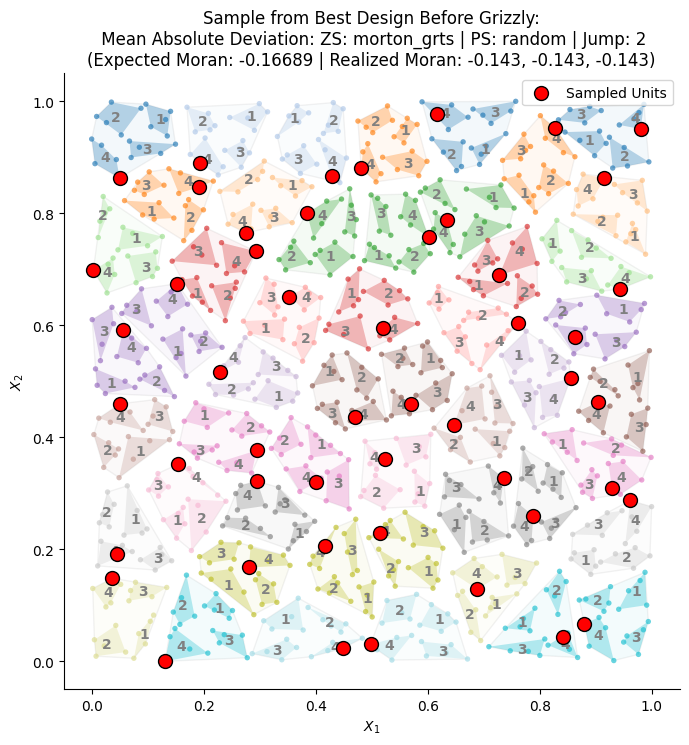

Sampled Unit Indices: [768 388 775 905 780  13 396 143 400 403 921 542 929 161 677 943 816 176
 438 439 441 827  61 961 323  69 582 459 334 976 722 210 466 598  87 602
 347 860  93 222 351 354 994 740 228 358 743 235 368 766]


In [57]:
# Plot Initial Best, and a sample on it!
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use the best design
best_design = initial_design 

# 3. Draw the background (Clustering and Zones)
# synchronize plotting order
fbn.clusters = best_design.order.clusters

# plot
fbn.plot(
    mode='soft',
    ax=ax,
    show_zone_labels=True
)
# 4. Extract a SINGLE sample (2D array: 1 row, n columns)
sample_indices_2d = best_design.sample(1)
sample_indices = sample_indices_2d[0] 

# 5. Calculate Moran for this SPECIFIC realization
# We use the Moran indexer on the current coordinates
realized_moran_tille = Moran(best_design.pop, method='tille').score(sample_indices_2d)[0]
realized_moran_raphael = Moran(best_design.pop, method='raphael').score(sample_indices_2d)[0]
realized_moran_robertson = Moran(best_design.pop, method='robertson').score(sample_indices_2d)[0]

# 6. Scatter the sampled points in Red
all_coords = best_design.pop.coords
ax.scatter(
    all_coords[sample_indices, 0], 
    all_coords[sample_indices, 1], 
    color='red', 
    s=100, 
    edgecolors='black', 
    label='Sampled Units',
    zorder=15 
)

# 7. Update title with both Expected and Realized Moran
ax.set_title(f"Sample from Best Design Before Grizzly:\n Mean Absolute Deviation: ZS: {best[2]} | PS: {best[3]} | Jump: {shift_jump}\n(Expected Moran: {best_design.moran[0]:.5f} | Realized Moran: {realized_moran_tille:.3f}, {realized_moran_raphael:.3f}, {realized_moran_robertson:.3f})")
ax.legend()
plt.show()

print(f"Sampled Unit Indices: {sample_indices}")

In [41]:
initial_design = results[0][1]
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

In [42]:
# Saving Initial Best
current_file = save_design(initial_design)

✅ Design saved: best_designs\INITIAL_pop_C50Z4_pop_df_AggregatedPop1000_0514_2231.pkl


In [44]:
# Loading an initial design
# design = load_design(
#     "best_designs/INITIAL_pop_C20Z4_pop_df_RegularPop1000_0514_2126.pkl"
# )

# print(design.moran)

In [ ]:
raise KeyboardInterrupt("Execution stopped by user.")

KeyboardInterrupt: Execution stopped by user.

### GRIZZLY

In [21]:
# Loading a GRIZZLY (A Best with All its Open set!)
gbfs = load_gbfs_state('GRIZZLY_pop_C1Z1_score-0.6100_N=50_pop_df_AggregatedPop1000_0505_0912.pkl')

🚀 Grizzly Resumed!
Best Score Found: -0.610011
Hierarchy State:  1 Clusters
Frontier Size:    6420 candidates


50
--- Inclusion Probability Diagnostic ---
Total Design Mass: 50.000001 (Target: 50)
Max Absolute Deviation: 7.45e-10
Mean Absolute Deviation: 7.45e-10
✅ SUCCESS: Inclusion probabilities are perfectly preserved!


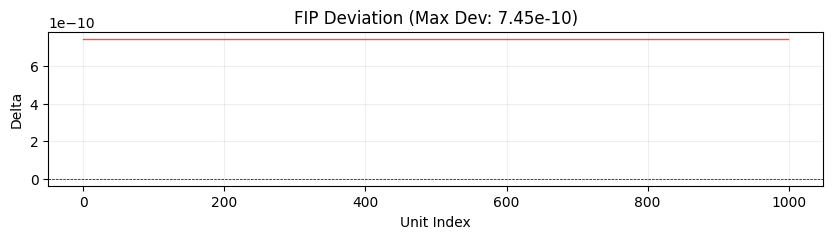

In [22]:
gbfs.best_design.moran
sample = gbfs.best_design.sample(1)

print(len(sample[0]))
check_inclusions(gbfs.best_design)

In [23]:
current_file = save_design(gbfs.best_design)

✅ Design saved: best_designs\INITIAL_pop_C1Z1_pop_df_AggregatedPop1000_0515_0044.pkl


In [ ]:
# Run GRIZZLY
gbfs.run(
    max_iterations=5000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier
    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)
    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples                           # (creates 20 candidate designs by changing sample order)
    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves                             # (0 means no swapping of units between samples)
    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters                     # (clusters are groups of zones processed together
    num_zones_range=(1,1),                # within a cluster, modify only 1 zone at a time
    num_changes_range=(1,1),              # each generated neighbor performs one order modification                             # (e.g., one swap/reposition in the sequence)
    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)
    pull_strategy='random',   # rule for selecting samples during exchange operations                          # (not used here since exchange neighbors are disabled)
    exchange_coef=.33,          # intensity of unit swapping during exchanges                         # (irrelevant here because num_new_exchange_nodes = 0)
    num_explore=1,               # number of designs expanded per iteration                       # (1 means purely greedy: always expand the current best design)
    window= None, #lambda iter: random.randint(1, 5)
    n_jobs = -1,
    backtrack_depth=1, 
    stagnation_limit=5000)
gbfs.initial_designs =  [gbfs.best_design]
check_inclusions(gbfs.best_design, plot=False)
# After your 100 iterations are done
# current_file = save_gbfs_state(gbfs)

In [ ]:
# Save a GRIZZLY
current_file = save_gbfs_state(gbfs)

In [ ]:
best_design = gbfs.best_design

### Global Searching Flatten GRIZZLY!

In [ ]:
# 1. Flatten the entire frontier
gbfs_global = release_full_grizzly(gbfs)

# 2. Grab the order from the NEW, flattened design
test_order = gbfs_global.best_design.order.copy()

--- Global Release Initiated ---
Processing 9880 candidates from the frontier...


✅ Success! New engine populated with 9881 global candidates.
Current Best Score: -0.430736


In [ ]:
test_order.change(
    num_clusters=1, 
    num_zones=1, 
    num_changes=1, 
    num_zone_changes=0, 
    window=120, 
    coords=pop.coords, 
    debugger_func=audit_intelligent_swap
)

TypeError: audit_intelligent_swap() got an unexpected keyword argument 'order'

In [ ]:
gbfs_global.run(
    max_iterations=2000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=5000,     # maximum number of candidate designs stored in the priority queue (search frontier)
    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)
    num_new_order_nodes=500,     # number of neighbors generated by modifying the ordering of samples
    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time
    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)
    pull_strategy='defult',   # rule for selecting samples during exchange operations
    exchange_coef=.005,          # intensity of unit swapping during exchanges
    num_explore=1,               # number of designs expanded per iteration
    window=100,
    n_jobs = -1,
    backtrack_depth=100, 
    stagnation_limit=5000,
    output_details=False,
)

In [ ]:
current_file = save_gbfs_state(gbfs_global)

C:\Users\Apc\AppData\Local\Temp\ipykernel_19020\1502334494.py:26: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(engine, f)


✅ Full search state saved: best_designs\GRIZZLY_pop_C1Z1_score-0.4259_pop_df_AggregatedPop1000_0502_2343.pkl
Candidates waiting in Open Set: 7449
